In [1]:
import gymnasium as gym
import humanoid_bench
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import xgboost as xgb
import imageio

In [2]:
env = gym.make('Pusher-v5',render_mode="rgb_array")
# env = gym.make('h1hand-stand-v0')
print(env.action_space)
print(env.observation_space)
# print(env.reward_range)

Box(-2.0, 2.0, (7,), float32)
Box(-inf, inf, (23,), float64)


(400, 7)
(400, 23)


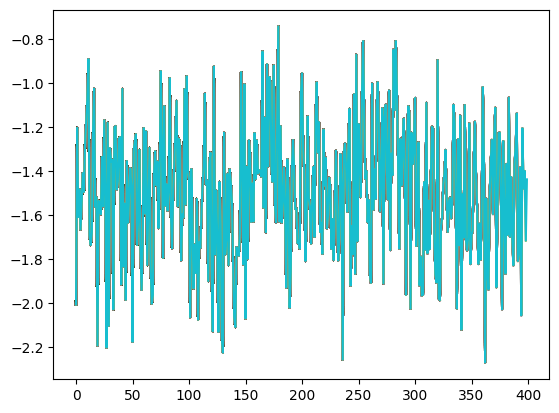

In [7]:
max_step = 400
iters = 1
OBS = []
ACTIONS = []
REWARDS = []
TIMES = []

for ite in range(iters):
    observation, info = env.reset(seed=515)
    env.action_space.seed(9515)
    actions = []
    observations = []
    rewards = []
    times = []
    for step in range(1,max_step+1):
        action = env.action_space.sample()
        # action = np.zeros(env.action_space.shape, dtype=np.float32) ## test with action = 0
        observation, reward, terminated, truncated, info = env.step(action)
        # done = terminated or truncated
        # if done:
        #     # print(step)
        #     break
        actions.append(action)
        observations.append(observation)
        rewards.append(reward)
        times.append(step)
        plt.plot(range(step),rewards)

    ACTIONS.append(actions)
    OBS.append(observations)
    REWARDS.append(np.array(rewards).reshape(-1,1))
    TIMES.append(np.array(times).reshape(-1,1))
ACTIONS_arr =  np.vstack(ACTIONS)
OBS_arr =  np.vstack(OBS)
REWARDS_arr =  np.vstack(REWARDS)
TIMES_arr =  np.vstack(TIMES)
print(ACTIONS_arr.shape)
print(OBS_arr.shape)
    

In [4]:
ACTIONS_arr

array([[ 0.6368554 , -1.616437  ,  1.8110969 , ...,  0.9056787 ,
         1.3464369 ,  1.9265499 ],
       [-0.6536449 ,  0.8808007 ,  0.4663829 , ..., -0.5474028 ,
        -1.7742873 ,  1.3886229 ],
       [ 1.8004466 ,  0.5403251 ,  0.891989  , ..., -1.3207973 ,
         0.96544784, -1.3644245 ],
       ...,
       [ 1.9965119 ,  0.82819945,  0.13417818, ..., -1.6378528 ,
        -0.13093859,  1.758823  ],
       [ 0.2665819 ,  0.9900639 ,  1.6939441 , ...,  0.5417638 ,
        -0.01555507,  1.0329938 ],
       [ 0.50561553, -0.8429954 , -0.8009086 , ..., -1.711696  ,
         1.4251684 ,  0.8187716 ]], dtype=float32)

(2000, 61)
(2000, 151)


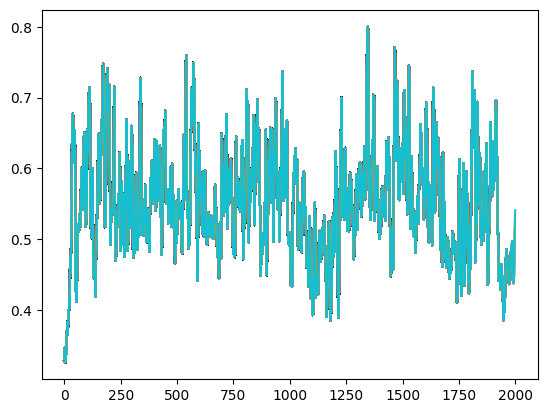

In [200]:
max_step = 2000
iters = 1
OBS = []
ACTIONS = []
REWARDS = []
TIMES = []

for ite in range(iters):
    observation, info = env.reset(seed=9515+ite)
    env.action_space.seed(515+ite)
    actions = []
    observations = []
    rewards = []
    times = []
    for step in range(1,max_step+1):
        action = env.action_space.sample()
        # action = np.zeros(env.action_space.shape, dtype=np.float32) ## test with action = 0
        observation, reward, terminated, truncated, info = env.step(action)
        # done = terminated or truncated
        # if done:
        #     # print(step)
        #     break
        actions.append(action)
        observations.append(observation)
        rewards.append(reward)
        times.append(step)
        plt.plot(range(step),rewards)

    ACTIONS.append(actions)
    OBS.append(observations)
    REWARDS.append(np.array(rewards).reshape(-1,1))
    TIMES.append(np.array(times).reshape(-1,1))
ACTIONS_arr =  np.vstack(ACTIONS)
OBS_arr =  np.vstack(OBS)
REWARDS_arr =  np.vstack(REWARDS)
TIMES_arr =  np.vstack(TIMES)
print(ACTIONS_arr.shape)
print(OBS_arr.shape)
    

In [17]:
def time_embedding_np(t, tdim=50):
    freqs = (2 * np.pi) / np.arange(2, tdim + 1, 2)  # shape: (tdim//2,)
    angles = np.outer(t, freqs)
    sin_emb = np.sin(angles)
    cos_emb = np.cos(angles)
    emb = np.concatenate([sin_emb, cos_emb], axis=-1)  # shape: (len(t), tdim)
    if emb.shape[0] == 1:
        return emb[0]  # return (tdim,) for scalar input
    return emb 

def save_state(env):
    env = env.unwrapped
    qpos = env.data.qpos.copy()
    qvel = env.data.qvel.copy()
    return qpos, qvel

def restore_state(env, qpos, qvel):
    env = env.unwrapped
    env.data.qpos[:] = qpos
    env.data.qvel[:] = qvel
    mujoco.mj_forward(env.model, env.data)

def one_step_from_state(env, actions):
    # save current simulator state (this corresponds to s_t)
    qpos, qvel = save_state(env)

    obs_list, rew_list, done_list, info_list = [], [], [], []

    for a in actions:
        # restore to s_t before trying each candidate action
        restore_state(env, qpos, qvel)

        obs_next, reward, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        obs_list.append(obs_next)
        rew_list.append(reward)
        done_list.append(done)
        info_list.append(info)

    # optional: restore original state again at the end
    restore_state(env, qpos, qvel)

    return (
        np.stack(obs_list, axis=0),
        np.array(rew_list),
        np.array(done_list),
        info_list,
    )

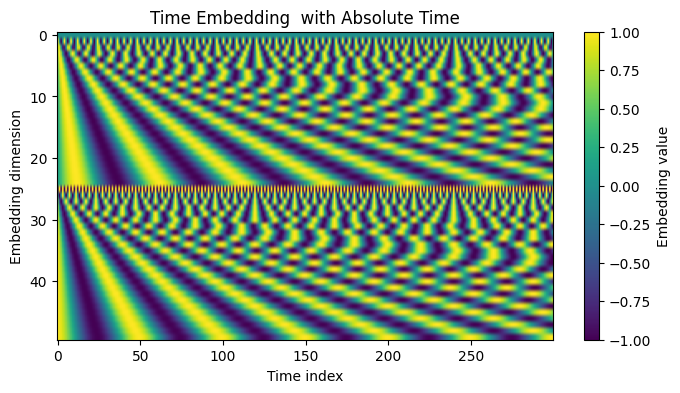

(300, 73)


In [18]:
time_emb = time_embedding_np(TIMES_arr, tdim=50)
features = np.hstack([OBS_arr, time_emb])
plt.figure(figsize=(8, 4))                
plt.imshow(time_emb.T, aspect='auto',        
           cmap='viridis',                 
           vmin=time_emb.min(),            
           vmax=time_emb.max())           
plt.colorbar(label='Embedding value')      
plt.title("Time Embedding  with Absolute Time")
plt.ylabel("Embedding dimension")
plt.xlabel("Time index")
plt.show()
print(features.shape)

In [19]:
def k_step_lookahead_traj(env, k, n_action, obs_t,seed = None):
    """
    From the CURRENT env state s_t, simulate k steps into the future.
    At each depth, from each node, sample n_action random actions from
    env.action_space and branch on them.

    We IGNORE terminated/truncated: always roll exactly k steps.

    Parameters
    ----------
    env : gym.Env
        env with continuous Box action space.
    k : int
        Lookahead depth (number of steps into the future).
    n_action : int
        Branching factor at each step.
    obs_t : np.ndarray
        Current observation at s_t (from last env.step or env.reset).

    Returns
    -------
    obs_tensor : np.ndarray, shape [num_rollouts, k+1, obs_dim]
        obs_tensor[i, t, :] is the observation at imagined step t along
        rollout i, with t=0 = current obs_t.
    act_tensor : np.ndarray, shape [num_rollouts, k, act_dim]
        act_tensor[i, t, :] is the action taken to go from
        obs_tensor[i, t] -> obs_tensor[i, t+1].
    """
    if seed is not None:
        env.action_space.seed(seed)

    e = env.unwrapped
    obs_t = np.asarray(obs_t, dtype=np.float32)
    obs_dim = obs_t.shape[0]

    # infer action dimension from a sample
    act_sample = env.action_space.sample()
    act_sample_arr = np.asarray(act_sample, dtype=np.float32)
    if act_sample_arr.shape == ():  # scalar (discrete), make it 1D
        act_dim = 1
    else:
        act_dim = act_sample_arr.shape[0]

    # local function
    def save_state():
        qpos = e.data.qpos.copy()
        qvel = e.data.qvel.copy()
        return qpos, qvel

    def restore_state(qpos, qvel):
        e.data.qpos[:] = qpos
        e.data.qvel[:] = qvel
        mujoco.mj_forward(e.model, e.data)

    # root state s_t
    root_state = save_state()

    # frontier nodes:
    #   "state": (qpos, qvel)
    #   "traj_obs": [obs0, obs1, ...]
    #   "traj_actions": [a0, a1, ...]  (len = len(traj_obs)-1)
    frontier = [{
        "state": root_state,
        "traj_obs": [obs_t],
        "traj_actions": [],
    }]

    for depth in range(k):
        new_frontier = []

        for node in frontier:
            qpos, qvel = node["state"]
            prefix_obs = node["traj_obs"]
            prefix_actions = node["traj_actions"]

            # branch with n_action random actions
            for _ in range(n_action):
                restore_state(qpos, qvel)

                action = env.action_space.sample()
                obs_next, reward, terminated, truncated, info = env.step(action)
                # we ignore terminated/truncated here

                child_state = save_state()

                new_frontier.append({
                    "state": child_state,
                    "traj_obs":    prefix_obs + [np.asarray(obs_next, dtype=np.float32)],
                    "traj_actions": prefix_actions + [np.asarray(action, dtype=np.float32)],
                })

        frontier = new_frontier

    # restore original s_t so planning doesn't change real env
    restore_state(*root_state)

    # build tensors
    num_rollouts = len(frontier)
    obs_tensor = np.zeros((num_rollouts, k + 1, obs_dim), dtype=np.float32)
    act_tensor = np.zeros((num_rollouts, k,     act_dim), dtype=np.float32)

    for i, node in enumerate(frontier):
        traj_obs = node["traj_obs"]       # length k+1
        traj_actions = node["traj_actions"]  # length k

        # fill obs
        for t, o in enumerate(traj_obs):
            obs_tensor[i, t, :] = o

        # fill actions
        for t, a in enumerate(traj_actions):
            a_arr = np.asarray(a, dtype=np.float32).reshape(-1)
            act_tensor[i, t, :len(a_arr)] = a_arr  # should match act_dim

    return obs_tensor, act_tensor


# Prospective Learning with Control

### Pretrain with random walk data

In [20]:
def make_weighted_target(rewards, gamma,T,normalization):
    """
    Given a 1D array `rewards` of length T (indexed 0..T-1),
    returns an array Y of length T such that for each t:
      Y[t] = sum_{k=1}^{T-t-1} alpha_k * rewards[t+k],
    where alpha_k ∝ gamma^(k-1) and sum alpha_k = 1.
    """
    Y = np.zeros(T)

    # Precompute all gamma-powers up to T-1
    gammas = gamma ** np.arange(0,T)  # [γ^0, γ^1, γ^2, …] 
    
    for t in range(T):
        L = T - (t+1)              # number of future steps
        if L <= 0:
            Y[t] = 0.0            # no future reward
            continue

        # raw weights ∝ [γ^0, γ^1, ..., γ^{L-1}]
        # print(L,t+1+L)
        raw = gammas[:L]          # length L
        # 
        if normalization:
            weights = raw / raw.sum() # normalize to sum=1
        else:
            weights =raw

        future_rewards = rewards[t+1 : t+1+L]
        # print(weights.shape, future_rewards.shape)
        Y[t] = np.dot(weights, future_rewards)

    return Y

def predict_paths(rf, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime))
    for i in range(t_prime):
        # if df_paths.shape[1] == 1:
        #     cand_pe = position_encoder(df_paths, type="onehot")
        # else:
        cand_pe = df_paths[:,i,:]
        curr_time = t_start + 1 + i + 1
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = rf.predict(features)
    return preds


In [ ]:
gamma = 0.99
prewards = make_weighted_target(REWARDS_arr, gamma,T = max_step,normalization = False)
X_train_oh = features
Y_train_action = REWARDS_arr
Y_train_value = prewards
print(X_train_oh.shape,Y_train_action.shape,Y_train_value.shape)
rf_value = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_value.fit(X_train_oh, Y_train_value)

rf_action = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)
# print(prewards)

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_95709/4043434906.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y[t] = np.dot(weights, future_rewards)


(300, 73) (300, 1) (300,)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


: 

In [ ]:
k = 5
n_action = 4
STEPS = 200
obs = observations[-1]
REWARDS = []
for step in range(STEPS):
    curr_step = max_step+step
    obs_tensor, act_tensor = k_step_lookahead_traj(env, k, n_action, obs,seed = 515)
    ## Calculate prospective reward for each trajctory
    pred_action = predict_paths(rf_action, obs_tensor[:,1:,:], curr_step, k)
    pred_value = predict_paths(rf_value, obs_tensor[:,-1:,:], curr_step+k, 1)
    rewards_matrix = np.hstack([pred_action,pred_value])
    discounts = gamma ** np.arange(0, k+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)

    ## Select the trajactory with the highest reward and execute this action
    best_idx = np.argmax(total_disc)
    chosen_action = act_tensor[best_idx,0,:]
    ACTIONS_arr =  np.vstack([ACTIONS_arr, chosen_action])
    
    next_obs, next_reward, terminated, truncated, info = env.step(chosen_action)

    ## Retrain with new actions, reward
    next_time = max_step+step+1
    next_features = np.hstack([next_obs.reshape(1,-1),time_embedding_np(next_time+1, tdim=50).reshape(1,-1)])
    X_train_oh = np.vstack([X_train_oh, next_features])
    Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])
    rf_action.fit(X_train_oh, Y_train_action)

    Y_train_value = make_weighted_target(Y_train_action, gamma ,T = next_time,normalization = False)
    rf_value.fit(X_train_oh, Y_train_value)

    obs = next_obs
    print(next_time,next_reward)
REWARD_random = Y_train_action

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_95709/4043434906.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y[t] = np.dot(weights, future_rewards)


301 -1.860144184721472
302 -1.447241193671735
303 -1.4503169428648417
304 -1.3371721898565678
305 -1.1891422247297532
306 -1.4627641763552155
307 -1.3492627925505256
308 -1.1997998551564288
309 -1.3554715598452993
310 -1.3592294801676195
311 -1.3623136857970009
312 -1.3645458705773685
313 -1.3658986517218838
314 -1.365778787283454
315 -1.896433021801351
316 -1.8955787011747307
317 -1.211796106849942
318 -1.3649549301399817
319 -1.2137074279745192
320 -1.3675864314827544
321 -1.216970783142177
322 -1.2201769054472271
323 -1.2248141444176754
324 -1.3819779080946182
325 -1.2343276596777224
326 -1.3914489005904618
327 -1.243705261708099
328 -1.2494955472542597
329 -1.4075962232797123
330 -1.4118057017214896
331 -1.263380035483073
332 -1.2685779142602307
333 -1.4260460867834799
334 -1.2783735908469314
335 -1.4352216260296005
336 -1.9712808740180947
337 -1.4444860667842339
338 -1.4474516610056973
339 -1.4485202742827137
340 -1.5651917167642413
341 -1.9796588004731752
342 -1.4492528165794092


In [ ]:
obs, info = env.reset(seed=515)
# print(obs)
frames = []
frames.append(env.render())   # frame at t=0

T = ACTIONS_arr.shape[0]
# T = 1000
for t in range(T):
    action = ACTIONS_arr[t]
    obs, reward, terminated, truncated, info = env.step(action)
    frames.append(env.render())
    # if terminated or truncated:
    #     print(t)
    #     break
# env.close()
imageio.mimsave("./results/gif/humanoid_push_envseed515_515_uniform.gif", frames, fps=30)

In [ ]:
ACTIONS_arr.shape

(2300, 61)

In [ ]:
np.savez(
    f"./results/plc/humanoid_push_envseed515_515_uniform_warmup300_online200_lookahea5_random4_gamma099_wo_normalized.npz",
    ACTIONS_arr = ACTIONS_arr,
    OBS_arr = X_train_oh,
    REWARDS_arr = Y_train_action, 
    )


In [186]:
fn = f"/Users/yuxinbai/Desktop/projects_repo/humanoid-bench/results/plc/humanoid_envseed9515_515_warmup800_online300_lookahea5_random4_gamma099_wo_normalized.npz"
data = np.load(fn)
ACTIONS_arr = data["ACTIONS_arr"]
REWARDS_arr_trained  = data["REWARDS_arr"]
print(ACTIONS_arr)

[[ 0.3184277  -0.8082185   0.90554845 ... -0.38265675  0.40705568
  -0.59909624]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]
 [ 0.8606518  -0.42991963 -0.929176   ... -0.8056794   0.25566635
  -0.51989746]
 ...
 [-0.9402809  -0.05976875  0.16253068 ...  0.41853437  0.63460594
  -0.11977122]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]]


In [258]:
REWARD_Trained = Y_train_action

In [55]:
k = 2
n_action = 4
STEPS = 300
obs = observations[-1]
REWARDS = []
for step in range(STEPS):
    curr_step = max_step+step
    obs_tensor, act_tensor = k_step_lookahead_traj(env, k, n_action, obs,seed = 515)
    ## Calculate prospective reward for each trajctory
    pred_action = predict_paths(rf_action, obs_tensor[:,1:,:], curr_step, k)
    pred_value = predict_paths(rf_value, obs_tensor[:,-1:,:], curr_step+k, 1)
    rewards_matrix = np.hstack([pred_action,pred_value])
    discounts = gamma ** np.arange(0, k+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)

    ## Select the trajactory with the highest reward and execute this action
    # best_idx = np.argmax(total_disc)
    best_idx = np.random.choice(range(act_tensor.shape[0]))
    chosen_action = act_tensor[best_idx,0,:]
    next_obs, next_reward, terminated, truncated, info = env.step(chosen_action)

    ## Retrain with new actions, reward
    next_time = max_step+step+1
    next_features = np.hstack([next_obs.reshape(1,-1),time_embedding_np(next_time+1, tdim=100).reshape(1,-1)])
    X_train_oh = np.vstack([X_train_oh, next_features])
    Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])
    # rf_action.fit(X_train_oh, Y_train_action)

    Y_train_value = make_weighted_target(Y_train_action, gamma ,T = next_time,normalization = False)
    # rf_value.fit(X_train_oh, Y_train_value)

    obs = next_obs
    print(next_time,next_reward)
REWARD_untrained = Y_train_action

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_42905/3618228879.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y[t] = np.dot(weights, future_rewards)


801 0.31776174444638744
802 0.3080770794502321
803 0.31216415475416537
804 0.31838592479481087
805 0.33082472562764054
806 0.34438552192277555
807 0.35630444933614613
808 0.3662676670521569
809 0.3718447230861012
810 0.3740462221306655
811 0.3740673463616886
812 0.37255411246985276
813 0.3694414051264842
814 0.36517266239774854
815 0.3541038209552907
816 0.34167373822618047
817 0.3312576132777257
818 0.3221704672795242
819 0.31247534092766815
820 0.31230826543193924
821 0.3277007887212389
822 0.3347149693901513
823 0.3364718639741366
824 0.34048438341337356
825 0.3360685520782842
826 0.4067804367094024
827 0.40225299448879426
828 0.4221678684914559
829 0.40977461701074813
830 0.3979243242211677
831 0.41251024038966516
832 0.404160768954141
833 0.40191677063531517
834 0.4008666186829898
835 0.3999554817991151
836 0.3861239051683353
837 0.3739975969309717
838 0.34657292087746683
839 0.40213594514493517
840 0.40222446371807374
841 0.40607945882488217
842 0.4007078931725951
843 0.358188955

In [46]:
REWARD_untrained

array([[0.33795375],
       [0.33625248],
       [0.35614257],
       ...,
       [0.33951441],
       [0.33170156],
       [0.3372443 ]])

In [1]:
# plt.plot(range(990),REWARD_untrained,c = 'blue',alpha = 0.5,label = 'random select from subset')
# plt.plot(range(1100),REWARDS_arr_trained[:1100], c = 'blue',alpha = 0.5, label = 'random select')
plt.plot(range(500),REWARDS_arr[:500], c = 'blue',alpha = 0.5, label = 'random select')
# plt.plot(range(1100),REWARD_Trained[:1100], c = 'red',alpha = 0.5,label = 'online policy update (uniformly select)')
plt.plot(range(500),REWARDS_arr_trained[:500], c = 'red',alpha = 0.5,label = 'online policy update (uniformly select) depth = 8, n_action = 3')
plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.ylabel('Reward')
plt.legend()

NameError: name 'plt' is not defined

### Only expand with top k child nodes:

In [25]:
def k_step_lookahead_traj_topk(env, k, n_action, k_action, obs_t, t, rf, seed=None):
    """
    k-step lookahead with action pruning using a trained RandomForest regressor.

    At each depth:
      1. From each node, sample n_action random actions.
      2. Predict value of next-state using rf(next_obs).
      3. Keep only the top k_action children.

      
    Parameters
    ----------
    env : gym.Env
    k : int
        Planning depth.
    n_action : int
        Number of random actions sampled per node.
    k_action : int
        Number of top-value actions to keep per node.
    obs_t : ndarray
        Current observation at root.
    rf : sklearn regressor
        Trained RandomForestRegressor predicting value from observation.
    """

    if seed is not None:
        env.action_space.seed(seed)
    rng = np.random.default_rng(seed)
    
    e = env.unwrapped
    obs_t = np.asarray(obs_t, dtype=np.float32)
    obs_dim = obs_t.shape[0]

    # Infer action dimension
    act_sample = env.action_space.sample()
    act_dim = np.asarray(act_sample).shape[-1] if np.asarray(act_sample).shape else 1

    # local helpers
    def save_state():
        return e.data.qpos.copy(), e.data.qvel.copy()

    def restore_state(qpos, qvel):
        e.data.qpos[:] = qpos
        e.data.qvel[:] = qvel
        mujoco.mj_forward(e.model, e.data)

    # root
    root_state = save_state()
    frontier = [{
        "state": root_state,
        "traj_obs":    [obs_t],
        "traj_actions": []
    }]

    # -------------------------
    # DEPTH LOOP
    # -------------------------
    for depth in range(k):
        new_frontier = []

        for node in frontier:
            qpos, qvel = node["state"]
            prefix_obs = node["traj_obs"]
            prefix_actions = node["traj_actions"]

            # store children temporarily: will prune later
            children = []

            # -------------------------
            # Sample n_action actions
            # -------------------------
            for _ in range(n_action):
                restore_state(qpos, qvel)

                action = env.action_space.sample()
                obs_next, reward, terminated, truncated, info = env.step(action)

                child_state = save_state()
                obs_next_arr = np.asarray(obs_next, dtype=np.float32)

                # -------------------------
                # Predict RF value of this next-state
                # rf expects shape (N, obs_dim)
                # -------------------------
                obs_next_time = np.hstack([obs_next_arr.reshape(1,-1),time_embedding_np(t+depth+1+1, tdim=100).reshape(1,-1)])
                value_est = float(rf.predict(obs_next_time.reshape(1, -1))[0])

                children.append({
                    "value": value_est,
                    "state": child_state,
                    "obs": obs_next_arr,
                    "action": np.asarray(action, dtype=np.float32),
                })

            # -------------------------
            # Select top-k_action children
            # -------------------------
            children.sort(key=lambda x: x["value"], reverse=True)

            num_top = max(k_action - 1, 0)
            top_children = children[:num_top]               # greedy
            remaining = children[num_top:]

            # random pick 2 from remaining (or fewer if not enough)
            num_rand = min(1, len(remaining))
            top_children += list(rng.choice(remaining, size=num_rand, replace=False))

            # -------------------------
            # Expand only top children
            # -------------------------
            for ch in top_children:
                new_frontier.append({
                    "state": ch["state"],
                    "traj_obs":    prefix_obs + [ch["obs"]],
                    "traj_actions": prefix_actions + [ch["action"]],
                })

        # frontier updated
        frontier = new_frontier

    # Restore original state
    restore_state(*root_state)

    # --------------------------------
    # Convert frontier → tensors
    # --------------------------------
    num_rollouts = len(frontier)
    obs_tensor = np.zeros((num_rollouts, k + 1, obs_dim), dtype=np.float32)
    act_tensor = np.zeros((num_rollouts, k,     act_dim), dtype=np.float32)

    for i, node in enumerate(frontier):
        for t, o in enumerate(node["traj_obs"]):
            obs_tensor[i, t] = o

        for t, a in enumerate(node["traj_actions"]):
            act_tensor[i, t] = a.reshape(-1)

    return obs_tensor, act_tensor


In [26]:
k = 5
n_action = 30
k_action = 4
STEPS = 500
obs = observations[-1]

for step in range(STEPS):
    curr_step = max_step+step
    obs_tensor, act_tensor = k_step_lookahead_traj_topk(env, k, n_action, k_action, obs, curr_step, rf_value, seed = 515)
    ## Calculate prospective reward for each trajctory
    pred_action = predict_paths(rf_action, obs_tensor[:,1:,:], curr_step, k)
    pred_value = predict_paths(rf_value, obs_tensor[:,-1:,:], curr_step+k, 1)
    rewards_matrix = np.hstack([pred_action,pred_value])
    discounts = gamma ** np.arange(0, k+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)

    ## Select the trajactory with the highest reward and execute this action
    best_idx = np.argmax(total_disc)
    chosen_action = act_tensor[best_idx,0,:]
    ACTIONS_arr =  np.vstack([ACTIONS_arr, chosen_action])
    
    next_obs, next_reward, terminated, truncated, info = env.step(chosen_action)

    ## Retrain with new actions, reward
    next_time = max_step+step+1
    next_features = np.hstack([next_obs.reshape(1,-1),time_embedding_np(next_time+1, tdim=100).reshape(1,-1)])
    X_train_oh = np.vstack([X_train_oh, next_features])
    Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])
    rf_action.fit(X_train_oh, Y_train_action)

    Y_train_value = make_weighted_target(Y_train_action, gamma ,T = next_time,normalization = False)
    rf_value.fit(X_train_oh, Y_train_value)

    obs = next_obs
    print(next_time,next_reward)
REWARD_greedy = Y_train_action
np.savez(
    f"./results/plc/humanoid_push_envseed515_515_warmup2000_online500_lookahea5_greedy4_gamma099_wo_normalized.npz",
    ACTIONS_arr = ACTIONS_arr,
    OBS_arr = X_train_oh,
    REWARDS_arr = REWARD_greedy, 
    )



/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_94830/3618228879.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y[t] = np.dot(weights, future_rewards)


2001 -2.4530603790417307
2002 -2.119562978508414
2003 -2.1885082887480722
2004 -1.3833953414486748
2005 -1.617384664862503
2006 -1.9279490584545314
2007 -1.9733558223051648
2008 -2.216371044060609
2009 -2.1888283136662805
2010 -2.2165348696743825
2011 -1.9737385662843048
2012 -2.1891354459777834
2013 -2.1701604457482615
2014 -1.9741104679781172
2015 -2.189491464511398
2016 -1.9294119176371676
2017 -1.9751854523989048
2018 -1.3857836221372541
2019 -1.4601010367138239
2020 -1.386582983999483
2021 -1.3868806635036384
2022 -1.7516470022343733
2023 -1.3874242663855716
2024 -2.17360311076554
2025 -1.3874879567774319
2026 -2.2201781878447737
2027 -2.1923914281351062
2028 -1.7516014897726007
2029 -1.7515159474729318
2030 -2.219720363710816
2031 -1.9767928831975572
2032 -1.7512484492578628
2033 -1.4888410566840453
2034 -2.2197171580431423
2035 -1.4608287277556955
2036 -1.9318206464597458
2037 -2.173251064718449
2038 -1.387143623321501
2039 -1.7515902371131027
2040 -1.387073236195567
2041 -2.219

KeyboardInterrupt: 

In [142]:
REWARD_greedy = Y_train_action[:1100]
np.savez(
    f"./results/plc/humanoid_envseed515_9515_warmup800_online300_lookahea5_greedy4_gamma099_wo_normalized.npz",
    ACTIONS_arr = ACTIONS_arr[:1100,:],
    OBS_arr = X_train_oh[:1100,:],
    REWARDS_arr = REWARD_greedy, 
    )

In [190]:
fn = f"./results/plc/humanoid_envseed9515_515_warmup800_online300_lookahea5_greedy4_gamma099_wo_normalized.npz"
data = np.load(fn)
ACTIONS_arr = data["ACTIONS_arr"]
# REWARDS_arr_trained  = data["REWARDS_arr"]
print(ACTIONS_arr)

[[ 0.3184277  -0.8082185   0.90554845 ... -0.38265675  0.40705568
  -0.59909624]
 [-0.1575639  -0.7239457  -0.54976547 ...  0.25696963 -0.05309033
   0.13409032]
 [ 0.8606518  -0.42991963 -0.929176   ... -0.8056794   0.25566635
  -0.51989746]
 ...
 [-0.27845183 -0.1892845  -0.12138758 ... -0.07063533  0.3869538
  -0.2719023 ]
 [ 0.7867565   0.21067975 -0.8811198  ...  0.9183788   0.5459105
  -0.83081657]
 [ 0.55518055 -0.45084405 -0.63653034 ...  0.67108935 -0.89546204
  -0.64685804]]


In [15]:
obs, info = env.reset(seed=515)
# print(obs)
frames = []
frames.append(env.render())   # frame at t=0

# T = ACTIONS_arr.shape[0]
# T= 970
T = 2000
for t in range(T):
    action = ACTIONS_arr[t]
    obs, reward, terminated, truncated, info = env.step(action)
    frames.append(env.render())
    # if terminated or truncated:
    #     print(t)
    #     break
# env.close()
imageio.mimsave("./results/gif/humanoid_push_envseed5515_random.gif", frames, fps=30)



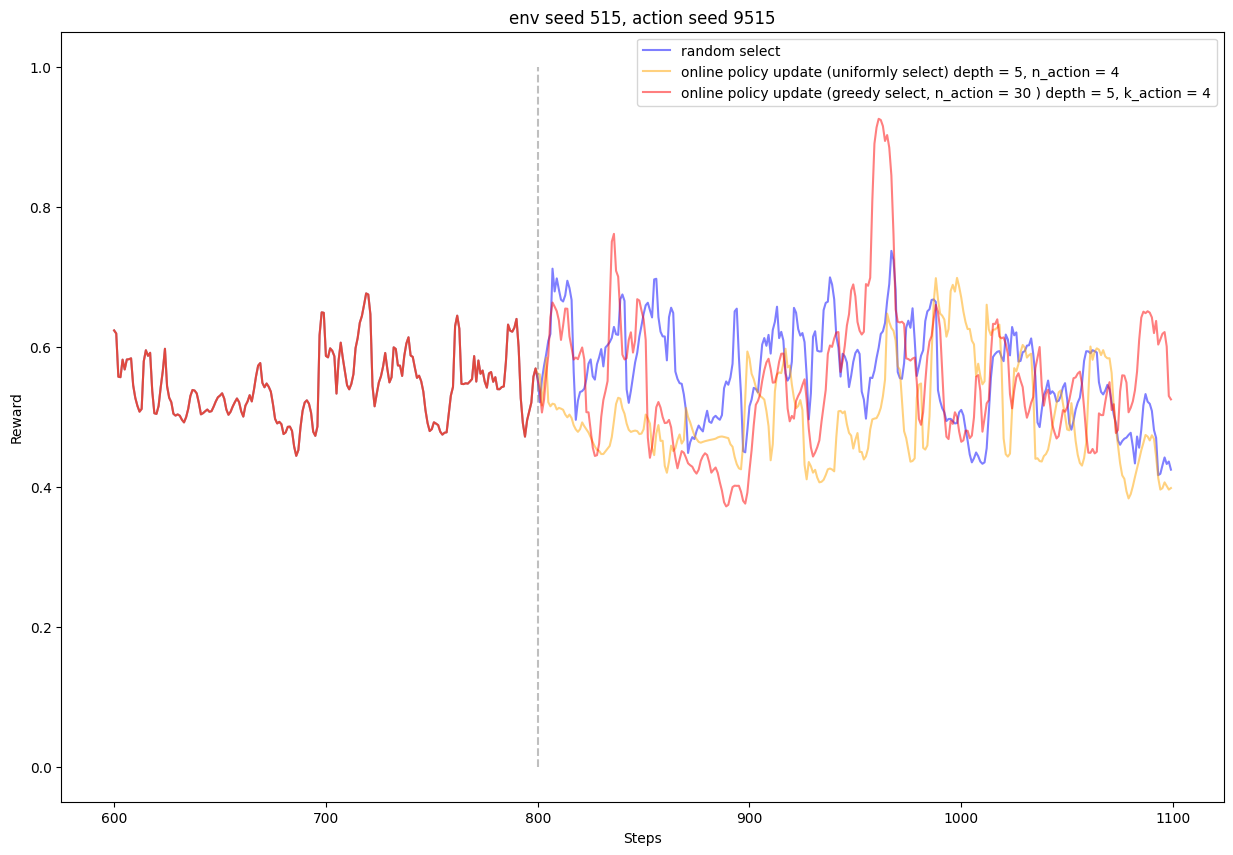

In [184]:
T = 1100
fig = plt.figure(figsize=(15, 10))
plt.plot(np.arange(T-500,T),REWARDS_arr[T-500:T], c = 'blue',alpha = 0.5, label = 'random select')
# plt.plot(range(1100),REWARD_Trained[:1100], c = 'red',alpha = 0.5,label = 'online policy update (uniformly sel
# ect)')
plt.plot(np.arange(T-500,T),REWARD_random[T-500:T], c = 'orange',alpha = 0.5,label = 'online policy update (uniformly select) depth = 5, n_action = 4')
# plt.plot(np.arange(T-500,T-300),REWARD_random[T-500:T-300], c = 'red',alpha = 0.5)
plt.plot(np.arange(T-500,T),REWARD_greedy[T-500:T], c = 'red',alpha = 0.5,label = 'online policy update (greedy select, n_action = 30 ) depth = 5, k_action = 4')
# plt.plot(np.arange(T-500,T),REWARD_greedy_normalized[T-500:T], c = 'red',alpha = 0.5,label = 'online policy update (greedy select, n_action = 20 ) depth = 5, k_action = 3')

plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.vlines(800,0,1,'grey','--',alpha = 0.5)
plt.ylabel('Reward')
plt.xlabel('Steps')
plt.title('env seed 515, action seed 9515')
plt.legend()

In [281]:
max(REWARD_greedy[-200:])

array([0.45977325])

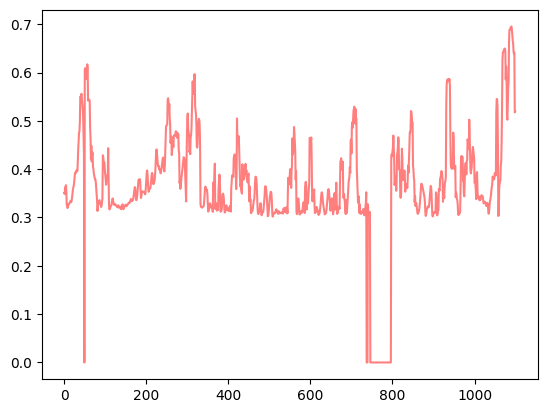

In [121]:
plt.plot(np.arange(0,T),REWARD_greedy, c = 'red',alpha = 0.5,label = 'online policy update (greedy select, n_action = 30 ) depth = 5, k_action = 4')